# In-Depth Analysis of Air Quality Index (AQI) in Delhi

# In-Depth Analysis of Air Quality Index (AQI) in Delhi

## Introduction

Delhi is one of the most polluted cities in the world. Air pollution caused by vehicular emissions, industrial activities, construction dust, and unfavorable weather conditions significantly affects public health. This project aims to analyze AQI-related pollutants in Delhi and identify key factors influencing air quality.

## Research Questions

1. Which pollutants contribute most to poor air quality in Delhi?

2. What relationship exists between PM2.5 and other pollutants?

3. How do pollutant concentrations vary over time?

4. Which pollutants are most strongly correlated?

5. What environmental challenges can be identified from AQI data?

## Dataset Description

The dataset contains hourly air pollution measurements collected in Delhi during January 2023. The dataset includes major pollutants such as PM2.5, PM10, CO, NO, NO2, SO2, NH3, and O3. These variables are used to analyze air quality patterns and identify key pollution sources.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('delhiaqi.csv')

df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


## Data Cleaning and Preprocessing

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.info()

NameError: name 'df' is not defined

In [ ]:
df.isnull().sum()

,0
date,0
co,0
no,0
no2,0
o3,0
so2,0
pm2_5,0
pm10,0
nh3,0


In [ ]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


## Statistical Analysis

The following statistical techniques were used:

- Descriptive Statistics
- Correlation Analysis
- Trend Analysis
- Distribution Analysis
- Outlier Detection

## Visualizations

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,day,weekday
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83,0,1,Sunday
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66,1,1,Sunday
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40,2,1,Sunday
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55,3,1,Sunday
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19,4,1,Sunday


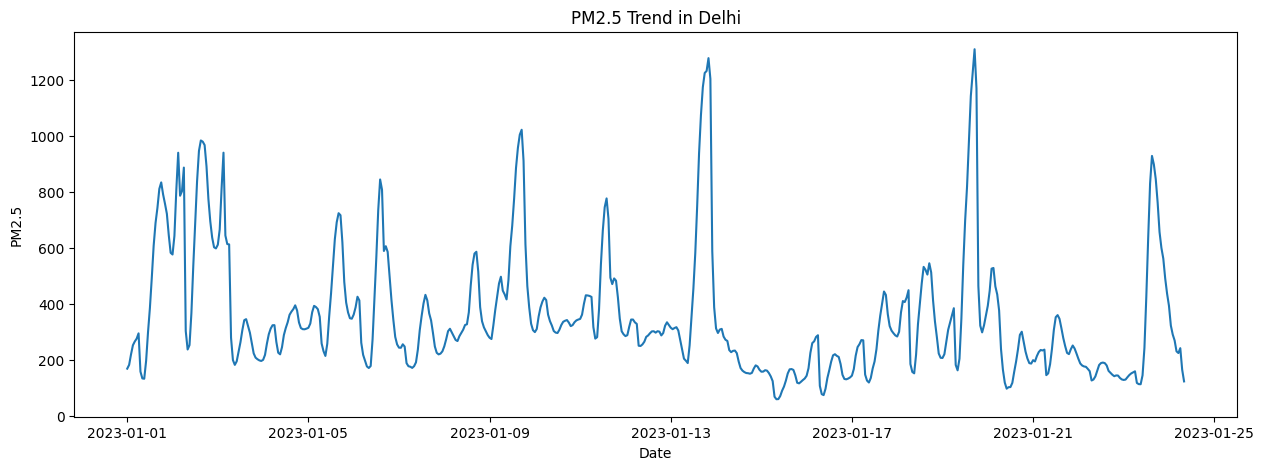

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['date'], df['pm2_5'])

plt.title('PM2.5 Trend in Delhi')
plt.xlabel('Date')
plt.ylabel('PM2.5')

plt.show()

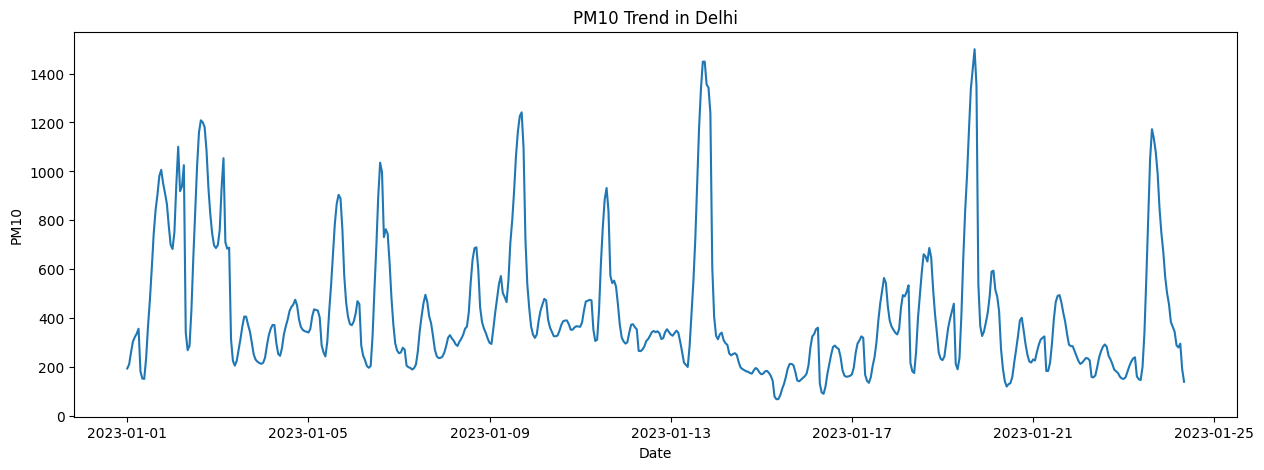

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df['date'], df['pm10'])

plt.title('PM10 Trend in Delhi')
plt.xlabel('Date')
plt.ylabel('PM10')

plt.show()

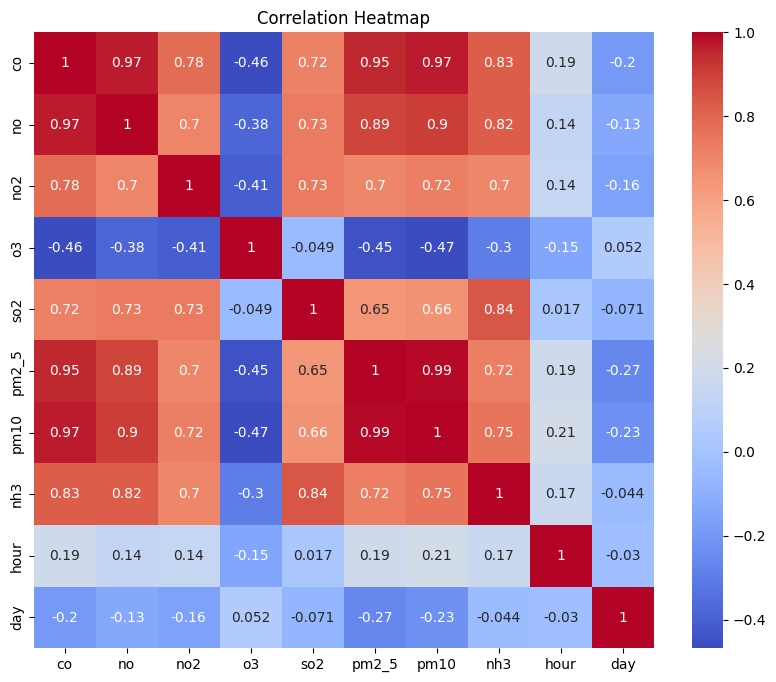

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

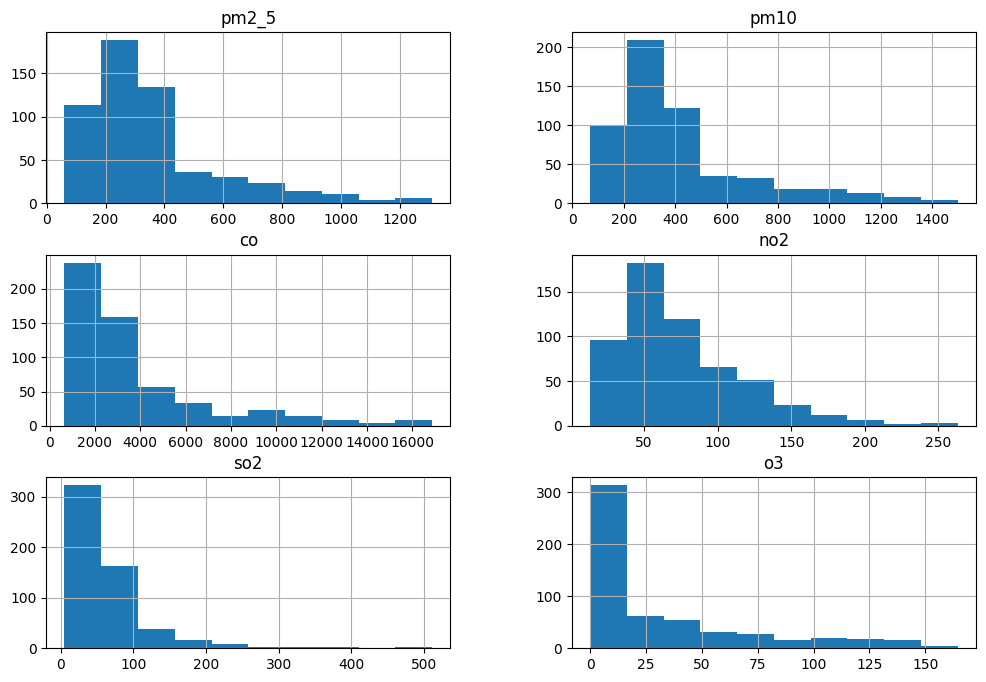

In [ ]:
df[['pm2_5','pm10','co','no2','so2','o3']].hist(
    figsize=(12,8)
)

plt.show()

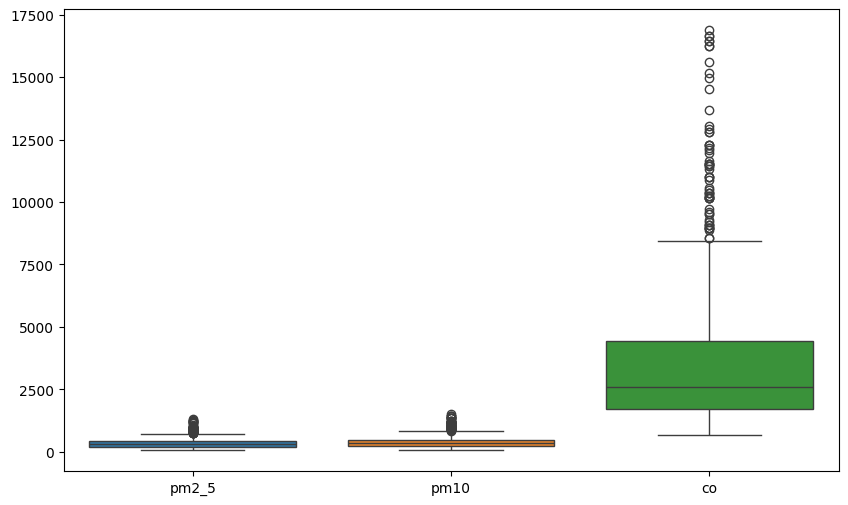

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[['pm2_5','pm10','co']]
)

plt.show()

In [ ]:
df.nlargest(
    10,
    'pm2_5'
)[['date','pm2_5','pm10','co']]

,date,pm2_5,pm10,co
449,2023-01-19 17:00:00,1310.20,1499.27,16662.60
308,2023-01-13 20:00:00,1278.35,1342.18,15594.48
307,2023-01-13 19:00:00,1232.62,1355.20,16235.35
448,2023-01-19 16:00:00,1228.04,1415.28,16448.97
306,2023-01-13 18:00:00,1225.39,1448.70,16662.60
309,2023-01-13 21:00:00,1204.33,1238.17,13671.88
305,2023-01-13 17:00:00,1174.70,1448.28,16876.22
450,2023-01-19 18:00:00,1170.46,1351.85,14526.37
447,2023-01-19 15:00:00,1142.61,1335.34,16448.97
304,2023-01-13 16:00:00,1074.91,1337.24,16235.35


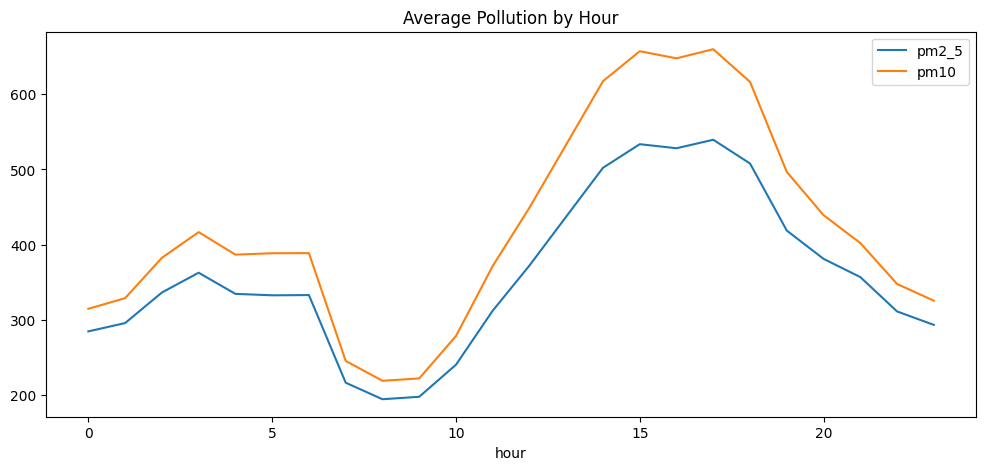

In [ ]:
# Average Pollution by Hour

hourly = df.groupby('hour')[['pm2_5','pm10']].mean()

hourly.plot(figsize=(12,5))
plt.title('Average Pollution by Hour')
plt.show()

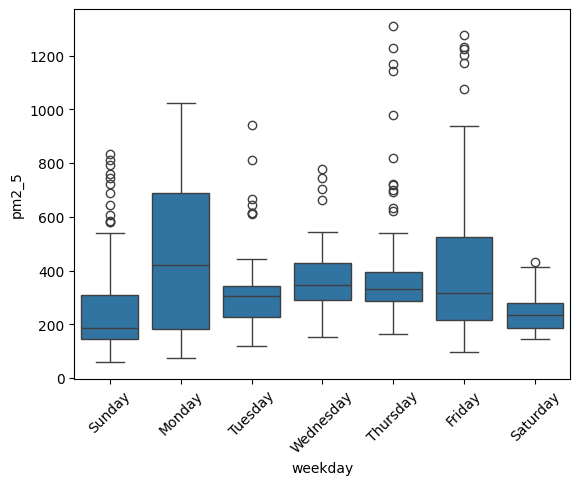

In [ ]:
# Weekday Analysis

sns.boxplot(
    x='weekday',
    y='pm2_5',
    data=df
)

plt.xticks(rotation=45)
plt.show()

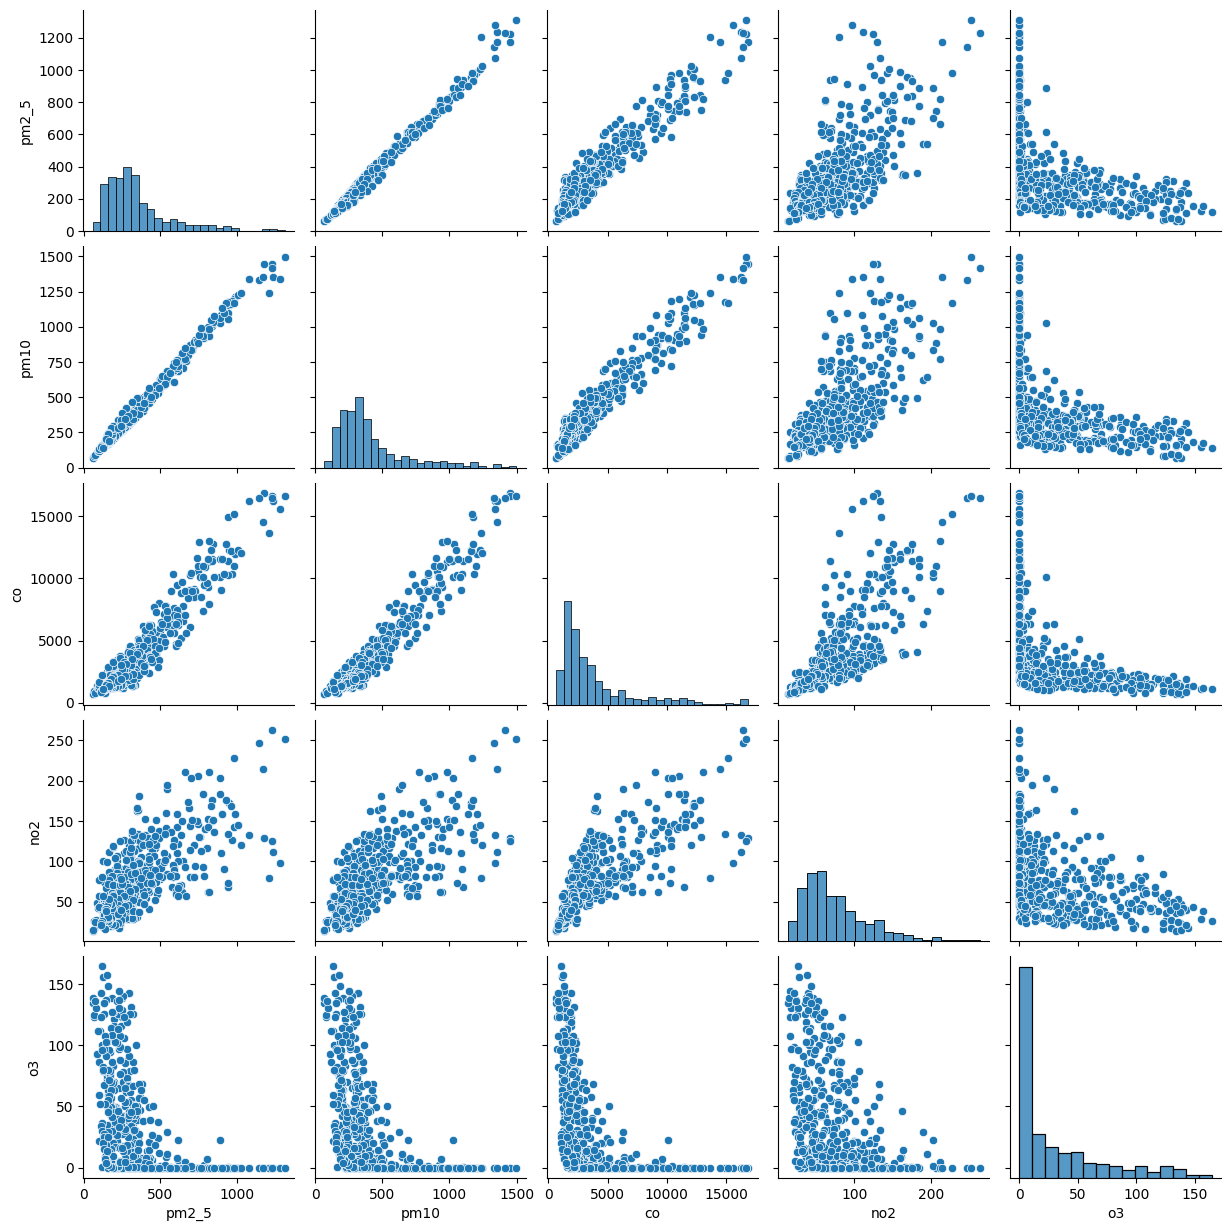

In [ ]:
# Pairplot

sns.pairplot(
    df[['pm2_5','pm10','co','no2','o3']]
)

plt.show()

## Findings

### RQ1: Which pollutants contribute most to poor air quality in Delhi?

PM2.5 and PM10 are the major pollutants affecting Delhi's air quality.

### RQ2: What relationship exists between PM2.5 and other pollutants?

PM2.5 shows a very strong positive correlation with PM10, CO and NO.

### RQ3: How do pollutant concentrations vary over time?

Pollutant concentrations fluctuate significantly and show several pollution spikes.

### RQ4: Which pollutants are most strongly correlated?

PM2.5 and PM10 show the strongest correlation.

### RQ5: What environmental challenges can be identified from AQI data?

Vehicular emissions, dust pollution and combustion activities are major environmental challenges.

## Recommendations

1. Promote public transportation and electric vehicles.

2. Reduce construction dust through stricter regulations.

3. Strengthen industrial emission monitoring.

4. Increase public awareness regarding AQI and health risks.

5. Implement region-wide pollution control strategies across Delhi NCR.

## Conclusion

The analysis reveals that PM2.5 and PM10 are the primary pollutants responsible for poor air quality in Delhi. Strong correlations among PM2.5, PM10, CO, and NO indicate significant contributions from vehicular emissions and combustion activities. Effective pollution control measures focusing on transportation, dust management, and emission reduction can improve air quality and public health outcomes.